# 2 - Busca de hiperparâmetros da GAIN

## Objetivo

Encontrar a **configuração de hiperparâmetros que minimiza o RMSE de imputação no val set**, o suficiente para atender ao critério de aceite da etapa: bater o melhor baseline (KNN, RMSE_norm ≈ 0,274 no val — protocolo da Etapa 3).

> **Pergunta que responde:** qual configuração do GAIN minimiza o erro de imputação no val set, suficientemente para superar o melhor baseline?

## Posição na Etapa 4

Notebook **2 de 3**. Pré-requisito: `01_treino.ipynb` (pipeline validado, GAIN inicial em 0,296 vs 0,274 do KNN no val). O diagnóstico do modelo vencedor fica para `03_diagnostico.ipynb`.

## Estratégia de busca

**Random search, não grid completo.** A grade abaixo tem 7 eixos e 1.296 combinações — a ~1 min por treino, o grid completo custaria ~22 h. Random search com 30 amostras cobre bem o espaço quando poucos eixos dominam o resultado (Bergstra & Bengio, JMLR 2012), que é exatamente a hipótese aqui: o diagnóstico do notebook 1 aponta o desequilíbrio adversarial/reconstrução como problema dominante. Amostramos **30 configurações + a configuração de referência do notebook 1** (para calibrar o proxy de busca contra um ponto conhecido).

**Proxy de busca barato, decisão formal cara.** Cada candidata treina com `n_iter=3000` (reduzido) e uma única seed, e é pontuada pelo melhor `rmse_val` da curva de validação (células `M=1, B=0` com `B` fixa — mesmo protocolo da curva do notebook 1). A decisão formal acontece só no finalista: treino cheio com 3 sementes e avaliação pelo protocolo completo da Etapa 3 (3 seeds de máscara, inversão de escala, RMSE por variável).

## Adaptação sobre o plano: o eixo `beta`

O plano (`Pipeline/04_GAIN/02_hyperparam.md`) prevê a busca sobre 6 eixos. Adicionamos um sétimo, **`beta`** — o peso de um termo supervisionado $\beta \cdot \text{MSE}$ nas células **escondidas artificialmente** ($M=1,\ B=0$), onde a verdade é conhecida. Justificativa registrada na síntese do notebook 1: depois que a reconstrução converge (~0,003), o gradiente do gerador é dominado ~100:1 pelo termo adversarial, que otimiza realismo distribucional, **não** RMSE. O termo supervisionado otimiza exatamente o que o RMSE de validação mede — é a leitura literal do protocolo de mascaramento de `06_mascaras.ipynb`. Com `beta=0` o modelo é o GAIN original do paper, então o eixo também responde se a extensão vale a pena. Implementação em `gain.train_gain` (retrocompatível).

## Caminhos

O plano cita `Data/Pipeline/`; os artefatos reais vivem em `Data/GoldData/` e `Data/ProcessedData/`, e os resultados vão para `Data/GainResults/` (`grid_results.csv`, `config_best.json`), `Data/Figures/04_GAIN/` (`grid_heatmaps.png`) e `checkpoints/` (`gain_best.pt`) — convenção do notebook 1.

## Setup

In [1]:
import json
import sys
import time
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

sys.path.append("../3 - Preprocessing")
sys.path.append("../4 - Baseline")
from mask_utils import generate_artificial_mask
import baseline_utils as bu
import gain

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device} | torch {torch.__version__}")

IN_SPLIT_DIR     = Path("../../Data/GoldData/Splited")
IN_MASK_DIR      = Path("../../Data/GoldData/Masked")
IN_COLUMNS_JSON  = Path("../../Data/ProcessedData/encoded_columns.json")
IN_SCALERS       = Path("../../Data/ProcessedData/scalers.pkl")
IN_TRANSFORM     = Path("../../Data/ProcessedData/transform_params.json")
IN_TAB_BASELINES = Path("../4 - Baseline/tabelas/tabela_baselines.csv")

OUT_CKPT_DIR = Path("./checkpoints")
OUT_RES_DIR  = Path("../../Data/GainResults")
OUT_FIG_DIR  = Path("../../Data/Figures/04_GAIN")
for p in (OUT_CKPT_DIR, OUT_RES_DIR, OUT_FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

OUT_GRID_CSV    = OUT_RES_DIR / "grid_results.csv"
OUT_CONFIG_JSON = OUT_RES_DIR / "config_best.json"
OUT_CKPT        = OUT_CKPT_DIR / "gain_best.pt"

device: cpu | torch 2.12.1+cpu


## Carregamento e preparação dos tensores

Idêntico ao notebook 1: as 11 variáveis-alvo viram `x`/`m`, as 23 features de contexto viram `ctx`, e a máscara artificial fixa do val (`miss_rate=0,20`, `seed=42` — protocolo da Etapa 3) define o conjunto de células sobre o qual **toda** a busca é pontuada.

In [2]:
with open(IN_COLUMNS_JSON, encoding="utf-8") as f:
    encoded_columns = json.load(f)
VARS = encoded_columns["numericas"]
CONTEXT_COLS = (encoded_columns["temporais"]
                + encoded_columns["estacao_onehot"]
                + encoded_columns["ld_onehot"])

df_train = pd.read_parquet(IN_SPLIT_DIR / "train.parquet")
df_val   = pd.read_parquet(IN_SPLIT_DIR / "val.parquet")
mask_real_train = pd.read_parquet(IN_MASK_DIR / "mask_real_train.parquet")
mask_real_val   = pd.read_parquet(IN_MASK_DIR / "mask_real_val.parquet")

# Pickle interno do projeto (gerado por 04_normalizacao.ipynb) — fonte confiável
scalers = joblib.load(IN_SCALERS)
with open(IN_TRANSFORM, encoding="utf-8") as f:
    transform_params = json.load(f)

def para_tensores(df, mask):
    x   = torch.tensor(df[VARS].fillna(0.0).to_numpy(dtype=np.float32))
    m   = torch.tensor(mask[VARS].to_numpy(dtype=np.float32))
    ctx = torch.tensor(df[CONTEXT_COLS].to_numpy(dtype=np.float32))
    return x, m, ctx

x_train, m_train, ctx_train = para_tensores(df_train, mask_real_train)
x_val,   m_val,   ctx_val   = para_tensores(df_val, mask_real_val)

assert not torch.isnan(ctx_train).any() and not torch.isnan(ctx_val).any()

ROBUSTAS = ["DBO", "OD", "pH", "Turbidez", "Temperatura da Água",
            "Condutividade", "Fósforo Total"]
INTERMEDIARIAS = ["Nitrato", "Nitrogênio Amoniacal Total", "Coliformes Termotolerantes"]
CRITICAS = ["Sólidos Suspensos Totais"]
MISS_RATES_PADRAO = {**{v: 0.20 for v in ROBUSTAS},
                     **{v: 0.10 for v in INTERMEDIARIAS},
                     **{v: 0.05 for v in CRITICAS}}
assert set(MISS_RATES_PADRAO) == set(VARS)
miss_rates_vec = np.array([MISS_RATES_PADRAO[v] for v in VARS], dtype=np.float32)

# B fixa do val — a busca inteira é pontuada sempre no mesmo conjunto de células
B_val = generate_artificial_mask(mask_real_val, miss_rate=0.20, seed=SEED)
b_val = torch.tensor(B_val.to_numpy(dtype=np.float32))

print(f"x_train {tuple(x_train.shape)} | x_val {tuple(x_val.shape)}")
print(f"células de validação escondidas (M=1, B=0): {int(((m_val == 1) & (b_val == 0)).sum())}")

x_train (515, 11) | x_val (34, 11)
células de validação escondidas (M=1, B=0): 68


## Grade de busca

O trade-off de cada eixo, para leitura dos resultados:

- **`hint_rate`** ∈ {0,5; 0,7; 0,9} — fração das células observadas que o discriminador já "sabe". Alto (0,9, valor do paper) facilita o jogo e reduz a pressão adversarial; baixo endurece o jogo e arrisca reeditar a dominância do D vista com a hint do paper.
- **`alpha`** ∈ {1; 10; 100} — peso da reconstrução nas células **mantidas** ($M_{ef}=1$). Alto ancora o gerador nos dados (privilegia RMSE); baixo privilegia o realismo distribucional. Alavanca nº 1 do diagnóstico do notebook 1.
- **`beta`** ∈ {0; 10; 100} — peso da supervisão nas células **escondidas** ($M=1, B=0$). É o único termo que otimiza diretamente a métrica de avaliação; `beta=0` é o GAIN original (o eixo mede o valor da extensão).
- **`batch_size`** ∈ {32; 64; 128} — com 515 linhas de treino, batch 128 é ~25% do dataset: gradiente estável mas poucas máscaras artificiais distintas por época; batch 32 vê mais padrões de mascaramento por passo de época, com mais ruído.
- **`hidden`** — {[64,64]; [128,128]; [128,128,128]; [256,128]}. Rede maior tem mais capacidade e mais risco de overfit num dataset minúsculo (515 × 34); a busca decide onde está o equilíbrio.
- **`lr_g`, `lr_d`** ∈ {1e-3; 5e-4} cada — independentes para permitir `lr_d < lr_g`, que contém a deriva do discriminador (alavanca nº 3 do notebook 1).

A amostragem usa o índice do produto cartesiano como `config_id` — estável entre execuções (a retomada pós-crash depende disso). A configuração do notebook 1 entra como `cfg_ref` para calibrar o proxy de `n_iter` reduzido.

In [3]:
GRID = {
    "hint_rate":  [0.5, 0.7, 0.9],
    "alpha":      [1, 10, 100],
    "beta":       [0, 10, 100],
    "batch_size": [32, 64, 128],
    "hidden":     [(64, 64), (128, 128), (128, 128, 128), (256, 128)],
    "lr_g":       [1e-3, 5e-4],
    "lr_d":       [1e-3, 5e-4],
}
N_SAMPLES = 30

combos = list(product(*GRID.values()))
rng_grid = np.random.default_rng(SEED)
idx_amostra = sorted(rng_grid.choice(len(combos), size=N_SAMPLES, replace=False))

configuracoes = [{"config_id": f"cfg_{i:04d}", **dict(zip(GRID, combos[i]))}
                 for i in idx_amostra]

# Configuração do notebook 1 (hp padrão do paper + beta=0) como referência
cfg_ref = {"config_id": "cfg_ref", "hint_rate": 0.9, "alpha": 10, "beta": 0,
           "batch_size": 64, "hidden": (128, 128), "lr_g": 1e-3, "lr_d": 1e-3}
if not any(c["config_id"] == "cfg_ref" or
           tuple(c[k] for k in GRID) == tuple(cfg_ref[k] for k in GRID)
           for c in configuracoes):
    configuracoes.append(cfg_ref)

print(f"espaço completo: {len(combos)} combinações | amostradas: {len(configuracoes)}")
pd.DataFrame(configuracoes).head()

espaço completo: 1296 combinações | amostradas: 31


,config_id,hint_rate,alpha,beta,batch_size,hidden,lr_g,lr_d
0,cfg_0109,0.5000,1,100,32,"(256, 128)",0.0010,0.0005
1,cfg_0113,0.5000,1,100,64,"(64, 64)",0.0010,0.0005
2,cfg_0120,0.5000,1,100,64,"(128, 128, 128)",0.0010,0.0010
3,cfg_0164,0.5000,10,0,64,"(128, 128)",0.0010,0.0010
4,cfg_0235,0.5000,10,10,128,"(128, 128, 128)",0.0005,0.0005


## Loop de busca

Cada configuração treina com `n_iter=3000` (vs 5000 do treino cheio) e seed única 42 — triagem, não decisão. O `train_gain` já devolve o gerador restaurado ao melhor ponto da curva de validação (early stopping implícito), então a pontuação é o **melhor** `rmse_val`, não o final.

Os resultados são gravados em `grid_results.csv` **a cada configuração** (proteção contra crash): reexecutar a célula retoma de onde parou, pulando os `config_id` já avaliados. Tempo estimado: ~1 min por configuração → **~30 min** no total (CPU).

In [4]:
%%time
N_ITER_BUSCA = 3000

resultados = (pd.read_csv(OUT_GRID_CSV, encoding="utf-8")
              if OUT_GRID_CSV.exists() else pd.DataFrame())
feitas = set(resultados["config_id"]) if len(resultados) else set()
print(f"configurações já avaliadas (retomada): {len(feitas)}\n")

for cfg in configuracoes:
    if cfg["config_id"] in feitas:
        continue
    hp_cfg = {k: cfg[k] for k in GRID}
    hp_cfg["hidden"] = list(cfg["hidden"])
    hp_cfg["n_iter"] = N_ITER_BUSCA
    t0 = time.perf_counter()
    _, _, log_i = gain.train_gain(
        x_train, m_train, ctx_train, hp_cfg, miss_rates=miss_rates_vec,
        val_data=(x_val, m_val, ctx_val, b_val), seed=SEED, eval_every=100)
    melhor_i = log_i.loc[log_i["rmse_val"].idxmin()]
    linha = {"config_id": cfg["config_id"],
             **{k: cfg[k] for k in GRID if k != "hidden"},
             "hidden": "-".join(map(str, cfg["hidden"])),
             "rmse_val": float(melhor_i["rmse_val"]),
             "iteracao_melhor": int(melhor_i["iteracao"]),
             "tempo_s": round(time.perf_counter() - t0, 1)}
    resultados = pd.concat([resultados, pd.DataFrame([linha])], ignore_index=True)
    resultados.to_csv(OUT_GRID_CSV, index=False, encoding="utf-8")  # incremental
    print(f"{linha['config_id']}: rmse_val={linha['rmse_val']:.4f} "
          f"@ iter {linha['iteracao_melhor']:>4d}  ({linha['tempo_s']:.0f}s)")

resultados = resultados.sort_values("rmse_val").reset_index(drop=True)
print(f"\nbusca completa: {len(resultados)} configurações | "
      f"tempo total de treino: {resultados['tempo_s'].sum() / 60:.0f} min")

configurações já avaliadas (retomada): 31


busca completa: 31 configurações | tempo total de treino: 9 min
CPU times: total: 0 ns
Wall time: 5.78 ms


## Análise da busca

Top 5 por `rmse_val` e a posição da configuração de referência do notebook 1. Em seguida, heatmaps de RMSE **marginal médio** para quatro pares de eixos.

> **Leitura com cautela:** com amostra aleatória de 30, cada célula do heatmap é a média de poucas configurações (o `n` está anotado) e os demais eixos não estão controlados — os mapas indicam tendências, não efeitos isolados. Células não amostradas ficam em cinza.

In [5]:
COLS_HP = ["hint_rate", "alpha", "beta", "batch_size", "hidden", "lr_g", "lr_d"]
top5 = resultados.head(5)[["config_id"] + COLS_HP + ["rmse_val", "iteracao_melhor"]]

pos_ref = int(resultados.index[resultados["config_id"] == "cfg_ref"][0]) + 1
rmse_ref = float(resultados.loc[resultados["config_id"] == "cfg_ref", "rmse_val"].iloc[0])
print(f"cfg_ref (hp do notebook 1, n_iter=3000): rmse_val={rmse_ref:.4f} — "
      f"posição {pos_ref} de {len(resultados)}")
print(f"melhor da busca: rmse_val={resultados['rmse_val'].iloc[0]:.4f} | "
      f"referências: GAIN inicial 0.3185 (curva, nb1) | KNN 0.274 (protocolo Etapa 3)")
top5

cfg_ref (hp do notebook 1, n_iter=3000): rmse_val=0.3232 — posição 29 de 31
melhor da busca: rmse_val=0.2355 | referências: GAIN inicial 0.3185 (curva, nb1) | KNN 0.274 (protocolo Etapa 3)


,config_id,hint_rate,alpha,beta,batch_size,hidden,lr_g,lr_d,rmse_val,iteracao_melhor
0,cfg_1092,0.9000,10,10,128,128-128,0.0010,0.0010,0.2355,1000
1,cfg_0941,0.9000,1,10,64,256-128,0.0010,0.0005,0.2551,1000
2,cfg_1079,0.9000,10,10,64,128-128,0.0005,0.0005,0.2569,2100
3,cfg_0643,0.7000,10,10,64,64-64,0.0005,0.0005,0.2627,2500
4,cfg_1246,0.9000,100,10,128,256-128,0.0005,0.0010,0.2635,1600


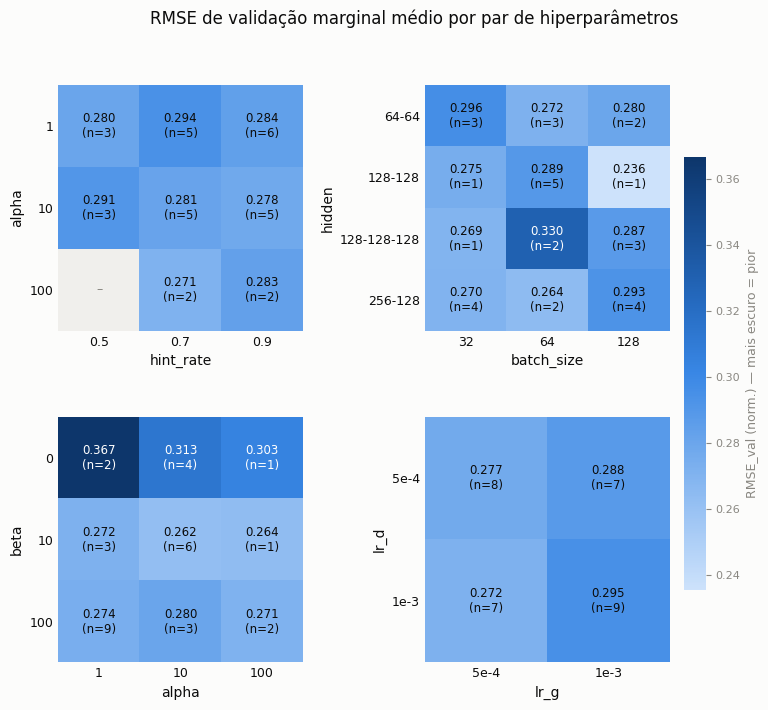

figura salva: ..\..\Data\Figures\04_GAIN\grid_heatmaps.png


In [6]:
# Heatmaps: RMSE marginal médio por par de hiperparâmetros (sequencial, 1 matiz)
SEQ_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
cmap_seq = LinearSegmentedColormap.from_list("azul_seq", SEQ_AZUL)
cmap_seq.set_bad("#f0efec")
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"

ORDEM = {"hidden": ["64-64", "128-128", "128-128-128", "256-128"],
         "lr_g": [5e-4, 1e-3], "lr_d": [5e-4, 1e-3]}
PARES = [("alpha", "hint_rate"), ("hidden", "batch_size"),
         ("beta", "alpha"), ("lr_d", "lr_g")]

def rotulo(eixo, valor):
    return f"{valor:.0e}".replace("e-0", "e-") if eixo.startswith("lr_") else str(valor)

vmin, vmax = resultados["rmse_val"].min(), resultados["rmse_val"].max()
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.5), facecolor=SURFACE)

for ax, (lin, col) in zip(axes.ravel(), PARES):
    medias = resultados.pivot_table(index=lin, columns=col, values="rmse_val", aggfunc="mean")
    ns     = resultados.pivot_table(index=lin, columns=col, values="rmse_val", aggfunc="count")
    idx = [v for v in ORDEM.get(lin, sorted(medias.index))]
    cols = [v for v in ORDEM.get(col, sorted(medias.columns))]
    medias, ns = medias.reindex(index=idx, columns=cols), ns.reindex(index=idx, columns=cols)

    im = ax.imshow(medias.to_numpy(), cmap=cmap_seq, vmin=vmin, vmax=vmax, aspect="auto")
    meio = (vmin + vmax) / 2
    for i in range(len(idx)):
        for j in range(len(cols)):
            v, n = medias.iloc[i, j], ns.iloc[i, j]
            if pd.isna(v):
                ax.text(j, i, "–", ha="center", va="center", color=MUTED, fontsize=9)
            else:
                cor_txt = "white" if v > meio else INK
                ax.text(j, i, f"{v:.3f}\n(n={int(n)})", ha="center", va="center",
                        color=cor_txt, fontsize=8.5)
    ax.set_xticks(range(len(cols)), [rotulo(col, v) for v in cols], fontsize=9, color=INK)
    ax.set_yticks(range(len(idx)), [rotulo(lin, v) for v in idx], fontsize=9, color=INK)
    ax.set_xlabel(col, fontsize=10, color=INK)
    ax.set_ylabel(lin, fontsize=10, color=INK)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# espaço extra entre os painéis: os rótulos de eixo y (ex.: "128-128-128")
# são largos e colidem com o painel vizinho no espaçamento padrão
fig.subplots_adjust(wspace=0.5, hspace=0.35)
fig.suptitle("RMSE de validação marginal médio por par de hiperparâmetros",
             fontsize=12, color=INK)
cbar = fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02)
cbar.set_label("RMSE_val (norm.) — mais escuro = pior", fontsize=9, color=MUTED)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=8, color=MUTED, labelcolor=MUTED)

fig.savefig(OUT_FIG_DIR / "grid_heatmaps.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"figura salva: {OUT_FIG_DIR / 'grid_heatmaps.png'}")

### Leitura da busca

- **`beta` é o eixo dominante.** As sete piores configurações da busca são exatamente as sete com `beta=0` (RMSE 0,302–0,367): *qualquer* configuração com o termo supervisionado bate *todas* as sem ele. No heatmap `beta × alpha`, a linha `beta=0` é visivelmente mais escura que o resto do mapa. E mais não é melhor: `beta=10` (média 0,265) supera `beta=100` (0,275), e o top 5 inteiro usa `beta=10`.
- **Sem `beta`, o "melhor ponto" das curvas é a iteração 100–200** — ou seja, a curva de validação degrada praticamente desde o início, exatamente o comportamento diagnosticado no notebook 1. Com `beta>0`, o melhor ponto tipicamente chega entre 500 e 2500 iterações: o treino passa a de fato aprender.
- **Os demais eixos são de segunda ordem.** As marginais de `hint_rate`, `alpha` e `batch_size` variam ~0,01 entre níveis — dentro do ruído de uma amostra de 31. A aparente vantagem de `lr_g=5e-4` (0,275 vs 0,292) é um bom exemplo do confundimento alertado acima: 5 das 7 configurações com `beta=0` sortearam `lr_g=1e-3`. Só a rede de 3 camadas (`128-128-128`) mostra leve desvantagem consistente.
- **`cfg_ref` (hp do notebook 1) ficou em 29º de 31** (0,3232) — próximo do 0,3185 do treino cheio do notebook 1, o que valida o proxy de `n_iter=3000` como triagem.
- A vencedora `cfg_1092` é **a configuração do notebook 1 com `beta=10` e batch 128** — a extensão supervisionada explica praticamente todo o ganho.

## Treino final da melhor configuração

A vencedora da triagem treina agora com `n_iter=5000` (cheio — o notebook 1 mostrou o melhor ponto em ~4500 e a curva oscila sem tendência depois disso) e **3 sementes** (42, 7, 2026 — as mesmas do protocolo da Etapa 3). GANs variam entre sementes; o checkpoint final é o da melhor seed pela curva de validação (`B` fixa), e a variação entre seeds entra na síntese como medida de estabilidade.

In [7]:
%%time
SEEDS_FINAIS = [42, 7, 2026]
N_ITER_FINAL = 5000

vencedora = resultados.iloc[0]
hp_best = {
    "hint_rate":  float(vencedora["hint_rate"]),
    "alpha":      float(vencedora["alpha"]),
    "beta":       float(vencedora["beta"]),
    "batch_size": int(vencedora["batch_size"]),
    "hidden":     [int(h) for h in vencedora["hidden"].split("-")],
    "lr_g":       float(vencedora["lr_g"]),
    "lr_d":       float(vencedora["lr_d"]),
    "n_iter":     N_ITER_FINAL,
}
print(f"configuração vencedora ({vencedora['config_id']}): "
      f"{ {k: v for k, v in hp_best.items() if k != 'n_iter'} }\n")

finais = {}
for s in SEEDS_FINAIS:
    G_s, D_s, log_s = gain.train_gain(
        x_train, m_train, ctx_train, hp_best, miss_rates=miss_rates_vec,
        val_data=(x_val, m_val, ctx_val, b_val), seed=s, eval_every=100)
    melhor_s = log_s.loc[log_s["rmse_val"].idxmin()]
    finais[s] = {"G": G_s, "D": D_s, "log": log_s,
                 "rmse": float(melhor_s["rmse_val"]),
                 "iteracao": int(melhor_s["iteracao"])}
    print(f"seed {s:>4d}: melhor rmse_val={finais[s]['rmse']:.4f} "
          f"@ iter {finais[s]['iteracao']}")

seed_melhor = min(finais, key=lambda s: finais[s]["rmse"])
G, D = finais[seed_melhor]["G"], finais[seed_melhor]["D"]
rmses_seeds = [finais[s]["rmse"] for s in SEEDS_FINAIS]
print(f"\nseed escolhida: {seed_melhor} | rmse_val entre seeds: "
      f"média {np.mean(rmses_seeds):.4f} ± {np.std(rmses_seeds):.4f}")

configuração vencedora (cfg_1092): {'hint_rate': 0.9, 'alpha': 10.0, 'beta': 10.0, 'batch_size': 128, 'hidden': [128, 128], 'lr_g': 0.001, 'lr_d': 0.001}



seed   42: melhor rmse_val=0.2355 @ iter 1000


seed    7: melhor rmse_val=0.2765 @ iter 800


seed 2026: melhor rmse_val=0.2748 @ iter 100

seed escolhida: 42 | rmse_val entre seeds: média 0.2623 ± 0.0189
CPU times: total: 11min 12s
Wall time: 60 s


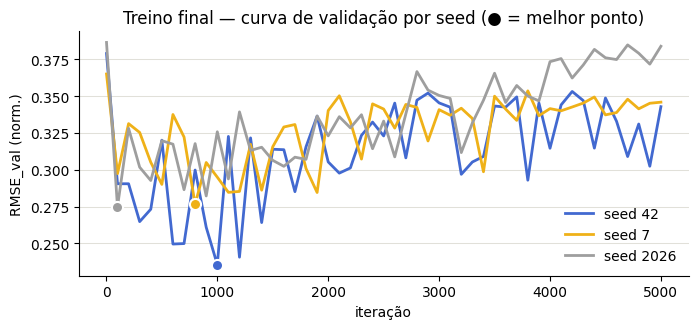

In [8]:
AZUL, LARANJA, CINZA = "#4269d0", "#efb118", "#9e9e9e"
CORES_SEED = dict(zip(SEEDS_FINAIS, [AZUL, LARANJA, CINZA]))

fig, ax = plt.subplots(figsize=(7, 3.4))
for s in SEEDS_FINAIS:
    log_s = finais[s]["log"]
    ax.plot(log_s["iteracao"], log_s["rmse_val"], color=CORES_SEED[s],
            lw=2, label=f"seed {s}")
    ax.plot(finais[s]["iteracao"], finais[s]["rmse"], "o", ms=8,
            color=CORES_SEED[s], mec="white", mew=1.5)
ax.set_xlabel("iteração")
ax.set_ylabel("RMSE_val (norm.)")
ax.set_title("Treino final — curva de validação por seed (● = melhor ponto)")
ax.legend(frameon=False)
ax.grid(axis="y", color="#e1e0d9", lw=0.75)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "curvas_treino_final.png", dpi=150, bbox_inches="tight")
plt.show()

## Avaliação no val — protocolo da Etapa 3

Decisão formal do critério de aceite: `gain_best` e o KNN (campeão da Etapa 3, reavaliado no val) medidos **nas mesmas células**, com o protocolo completo — 3 seeds de máscara artificial (`miss_rate=0,20`), imputação, inversão de escala e RMSE por variável. A última tabela junta a referência do melhor baseline por variável medido no **test** (contexto, não comparação direta).

In [9]:
G.eval()

def predict_gain(X_obs, seed=None):
    m_obs = torch.tensor(X_obs.notna().to_numpy(dtype=np.float32))
    x_obs = torch.tensor(X_obs.fillna(0.0).to_numpy(dtype=np.float32))
    x_imp = gain.impute(G, x_obs, m_obs, ctx_val)
    return pd.DataFrame(x_imp.numpy(), columns=VARS, index=X_obs.index)

met_gain, pred_gain = bu.avaliar_baseline(
    "gain_best", predict_gain, df_val, mask_real_val,
    VARS, scalers, transform_params, seeds=[42, 7, 2026], miss_rate=0.20,
    generate_artificial_mask=generate_artificial_mask)

met_gain.groupby("variavel", sort=False)[["RMSE", "RMSE_norm", "n_avaliado"]].mean().round(4)

,RMSE,RMSE_norm,n_avaliado
variavel,,,
DBO,14.1622,0.2520,7.0000
OD,2.2099,0.2823,5.0000
Nitrato,0.0212,0.3733,1.3333
Nitrogênio Amoniacal Total,1.8327,0.2463,9.0000
Fósforo Total,0.9908,0.0917,5.6667
Condutividade,7539.7758,0.2349,5.6667
pH,0.2626,0.1167,8.0000
Turbidez,24.9750,0.1500,8.6667
Temperatura da Água,1.4681,0.1468,6.3333


In [10]:
# KNN (campeão da Etapa 3) avaliado nas MESMAS células do val, para comparação justa
from sklearn.impute import KNNImputer

FEATURES = VARS + CONTEXT_COLS
train_feat = df_train[FEATURES]

def predict_knn_val(X_obs, seed=None):
    imp = KNNImputer(n_neighbors=5, weights="distance")
    imp.fit(train_feat)
    out = imp.transform(pd.concat([X_obs, df_val[CONTEXT_COLS]], axis=1))
    return pd.DataFrame(out, columns=FEATURES, index=X_obs.index)[VARS]

met_knn_val, _ = bu.avaliar_baseline(
    "knn", predict_knn_val, df_val, mask_real_val,
    VARS, scalers, transform_params, seeds=[42, 7, 2026], miss_rate=0.20,
    generate_artificial_mask=generate_artificial_mask)

comp = pd.DataFrame({
    "GAIN_best":  met_gain.groupby("variavel", sort=False)["RMSE_norm"].mean(),
    "KNN (val)":  met_knn_val.groupby("variavel", sort=False)["RMSE_norm"].mean(),
    "n_avaliado": met_gain.groupby("variavel", sort=False)["n_avaliado"].sum(),
})
comp["GAIN vence"] = comp["GAIN_best"] < comp["KNN (val)"]

rmse_gain_protocolo = float(met_gain["RMSE_norm"].mean())
rmse_knn_protocolo  = float(met_knn_val["RMSE_norm"].mean())
criterio_ok = rmse_gain_protocolo <= rmse_knn_protocolo
print(f"RMSE_norm médio  —  GAIN_best: {rmse_gain_protocolo:.4f}  |  "
      f"KNN: {rmse_knn_protocolo:.4f}")
print(f"critério de aceite (GAIN ≤ KNN no val): {'ATENDIDO ✅' if criterio_ok else 'NÃO atendido ❌'}")
comp.round(4)

RMSE_norm médio  —  GAIN_best: 0.2317  |  KNN: 0.2742
critério de aceite (GAIN ≤ KNN no val): ATENDIDO ✅


,GAIN_best,KNN (val),n_avaliado,GAIN vence
variavel,,,,
DBO,0.2520,0.2980,21,True
OD,0.2823,0.3963,15,True
Nitrato,0.3733,0.3493,4,False
Nitrogênio Amoniacal Total,0.2463,0.3252,27,True
Fósforo Total,0.0917,0.1108,17,True
Condutividade,0.2349,0.2092,17,False
pH,0.1167,0.1749,24,True
Turbidez,0.1500,0.1869,26,True
Temperatura da Água,0.1468,0.1762,19,True


In [11]:
# Referência da Etapa 3 (medida no TEST — contexto, não comparação direta)
tabela_baselines = pd.read_csv(IN_TAB_BASELINES, encoding="utf-8")
melhor_test = (tabela_baselines
               .loc[tabela_baselines.groupby("variavel")["RMSE_norm_media"].idxmin()]
               [["variavel", "metodo", "RMSE_norm_media"]]
               .rename(columns={"metodo": "melhor_baseline_test",
                                "RMSE_norm_media": "RMSE_norm_test"})
               .set_index("variavel"))
comp.join(melhor_test).round(4)

,GAIN_best,KNN (val),n_avaliado,GAIN vence,melhor_baseline_test,RMSE_norm_test
variavel,,,,,,
DBO,0.2520,0.2980,21,True,knn,0.2088
OD,0.2823,0.3963,15,True,mice,0.2558
Nitrato,0.3733,0.3493,4,False,media_global,0.6194
Nitrogênio Amoniacal Total,0.2463,0.3252,27,True,missforest,0.4635
Fósforo Total,0.0917,0.1108,17,True,missforest,0.1621
Condutividade,0.2349,0.2092,17,False,mice,0.2109
pH,0.1167,0.1749,24,True,missforest,0.1982
Turbidez,0.1500,0.1869,26,True,mice,0.1728
Temperatura da Água,0.1468,0.1762,19,True,mice,0.2254


## Salvamento

`gain_best.pt` (pesos da melhor seed, G já restaurado ao melhor ponto de validação) e `config_best.json` (hiperparâmetros + métricas — o contrato de entrada de `03_diagnostico.ipynb`).

In [12]:
ckpt = {
    "G_state": G.state_dict(),           # melhor estado por rmse_val (early stopping implícito)
    "D_state": D.state_dict(),
    "hp": hp_best,
    "vars": VARS,
    "context_cols": CONTEXT_COLS,
    "seed": seed_melhor,
    "iteracao_melhor": finais[seed_melhor]["iteracao"],
    "rmse_val_melhor_norm": finais[seed_melhor]["rmse"],
    "rmse_val_protocolo_etapa3": rmse_gain_protocolo,
}
torch.save(ckpt, OUT_CKPT)

config_best = {
    "config_id": str(vencedora["config_id"]),
    "hp": hp_best,
    "seed_melhor": seed_melhor,
    "seeds_finais": SEEDS_FINAIS,
    "rmse_val_por_seed": {str(s): finais[s]["rmse"] for s in SEEDS_FINAIS},
    "iteracao_melhor": finais[seed_melhor]["iteracao"],
    "rmse_val_curva_norm": finais[seed_melhor]["rmse"],
    "rmse_val_protocolo_etapa3": rmse_gain_protocolo,
    "rmse_val_knn_protocolo": rmse_knn_protocolo,
    "criterio_aceite_ok": bool(criterio_ok),
    "n_configuracoes_busca": int(len(resultados)),
    "rmse_por_variavel": {v: {"gain": float(comp.loc[v, "GAIN_best"]),
                              "knn": float(comp.loc[v, "KNN (val)"])}
                          for v in comp.index},
}
with open(OUT_CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(config_best, f, ensure_ascii=False, indent=2)

print(f"checkpoint salvo: {OUT_CKPT} ({OUT_CKPT.stat().st_size / 1024:.0f} KB)")
print(f"configuração salva: {OUT_CONFIG_JSON}")

checkpoint salvo: checkpoints\gain_best.pt (192 KB)
configuração salva: ..\..\Data\GainResults\config_best.json


## Síntese final

### Configuração vencedora

`cfg_1092` — a configuração do notebook 1 acrescida do termo supervisionado (`beta=10`) e de batch maior:

| hiperparâmetro | valor |
|---|---|
| `hint_rate` | 0,9 |
| `alpha` | 10 |
| **`beta`** | **10** |
| `batch_size` | 128 |
| `hidden` | [128, 128] |
| `lr_g` / `lr_d` | 1e-3 / 1e-3 |

Treino final com 5000 iterações e 3 sementes: melhor seed **42** (rmse_val 0,2355 na curva, iteração 1000); entre sementes, 0,2623 ± 0,0189 — mesmo a **média** entre seeds fica abaixo do KNN na curva de validação.

### Bate o melhor baseline? Sim — critério de aceite da etapa **atendido**

Protocolo da Etapa 3 no val (3 seeds de máscara, `miss_rate=0,20`, mesmas células para os dois métodos):

| Métrica (val, protocolo Etapa 3) | GAIN_best | KNN (val) |
|---|---:|---:|
| RMSE_norm médio | **0,2317** | 0,2742 |
| Variáveis onde vence (11) | **9** | 2 |

Ganho de ~15% sobre o campeão da Etapa 3 (o GAIN inicial perdia: 0,296). Maiores vantagens: **OD** (0,282 vs 0,396), **Nitrogênio Amoniacal** (0,246 vs 0,325 — onde o notebook 1 perdia com folga), **pH** (0,117 vs 0,175), **Coliformes** (0,110 vs 0,187, n=3) e **SST** (0,505 vs 0,573 — a variável de cobertura crítica). Perde apenas em **Nitrato** (0,373 vs 0,349, n=4 — pouquíssimas células) e **Condutividade** (0,235 vs 0,209), a mesma variável problemática do notebook 1, agora com margem bem menor (era 0,382).

### O que a busca ensinou

O termo supervisionado `beta` explica praticamente todo o ganho: as 7 piores configurações são exatamente as 7 com `beta=0`, e o top 5 inteiro usa `beta=10` (`beta=100` já é pior). Os demais eixos são de segunda ordem — detalhes na seção *Leitura da busca*. Isso confirma o diagnóstico do notebook 1: o problema do GAIN puro neste dataset era o gradiente do gerador dominado pelo termo adversarial, que otimiza realismo distribucional, não RMSE.

### Ressalvas

- **Estabilidade entre sementes** é a fragilidade conhecida de GANs: 0,2355 / 0,2765 / 0,2748 — a seed 42 é um ponto feliz; ainda assim, a pior seed praticamente empata com o KNN. `03_diagnostico.ipynb` deve verificar se a vantagem sobrevive a critérios além do RMSE (distribuições imputadas, comportamento por estação).
- **Val pequeno** (34 coletas, ~68 células escondidas por seed): números indicativos; a confirmação formal acontece no test em `05_Evaluation` (referência lá: KNN 0,313). Nitrato e Coliformes têm n≤4 células avaliadas.
- `beta` otimiza diretamente a métrica de seleção — risco de sobreajuste ao protocolo de mascaramento; mitigado porque a decisão formal usa 3 seeds de máscara distintas da `B` fixa da curva de treino.

### Critério de aceite do notebook

- ✅ `gain_best.pt` e `config_best.json` salvos.
- ✅ `grid_results.csv` documenta as 31 configurações testadas (auditabilidade).
- ✅ RMSE médio do `gain_best` no val (0,2317) ≤ RMSE médio do melhor baseline (KNN, 0,2742).

## Próximo notebook

`03_diagnostico.ipynb` — diagnóstico do modelo final.